Classificazione SVM

In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler


In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target

display(pd.DataFrame(X, columns=data.feature_names))

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [7]:
display(pd.DataFrame(y, columns=["target"]))

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
svc_linear = SVC(kernel="linear", C=1.0, random_state=42)
svc_linear.fit(X_scaled, y)
y_pred_linear = svc_linear.predict(X_scaled)

In [10]:
svc_rbf = SVC(kernel="rbf", C=1.0, random_state=42)
svc_rbf.fit(X_scaled, y)
y_pred_rbf = svc_rbf.predict(X_scaled)

In [12]:
# facciamo un plot per vedere i confini che i due modelli hanno individuato
# andiamo a selezionare 2 feature per fare un grafico 2d

feature_0 = 0
feature_1 = 1
X_2d = X_scaled[:, [feature_0, feature_1]]

In [ ]:
# addestriamo i due modelli con il dataset ridotto

svc_linear_plot = SVC(kernel="linear", C=1.0, random_state=42).fit(X_2d, y)
svc_rbf_plot = SVC(kernel="rbf", C=1.0, random_state=42).fit(X_2d, y)


In [16]:
# griglia per dati equispaziati

x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

In [18]:
# rappresentazione grafica

Z_linear = svc_linear_plot.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_rbf = svc_rbf_plot.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

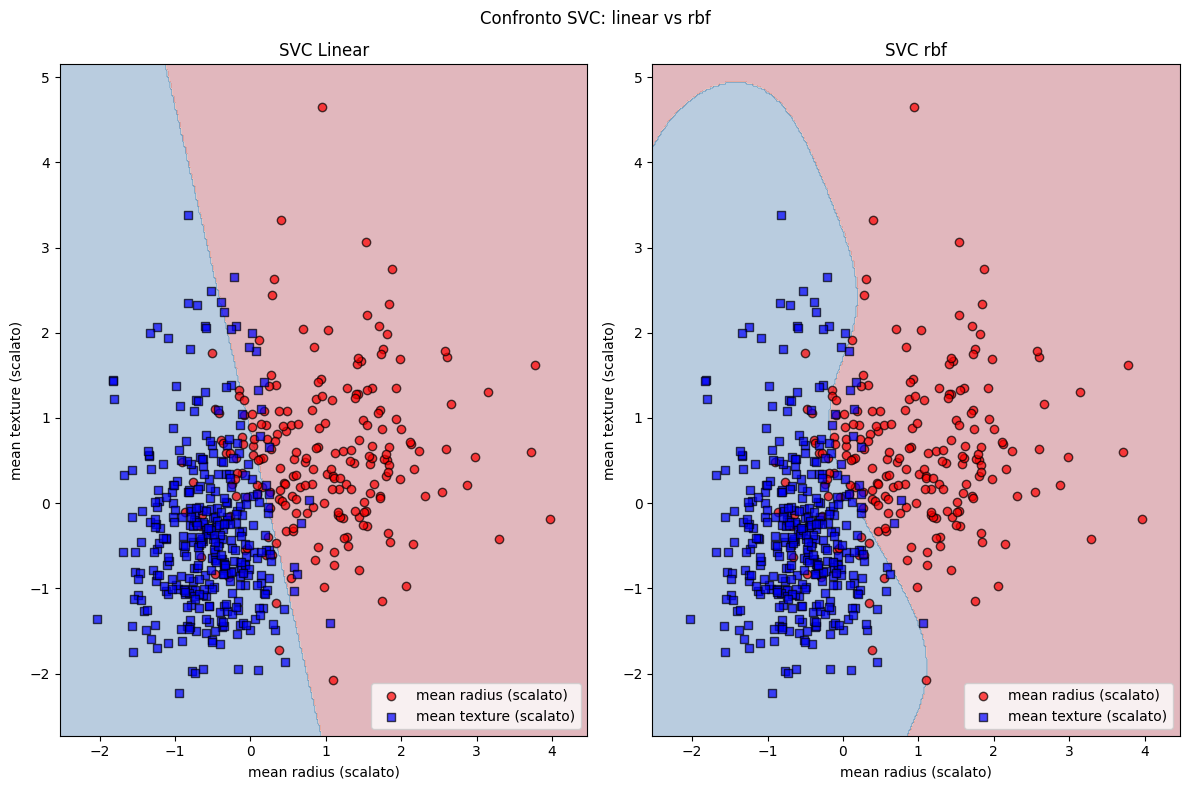

In [24]:
plt.figure(figsize = (12, 8))
plt.suptitle("Confronto SVC: linear vs rbf")

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_linear, alpha= 0.3, cmap=plt.cm.RdBu)
plt.scatter(X_2d[y==0, 0], X_2d[y==0, 1], c ="red", edgecolors="k", marker="o", label=f"{data.feature_names[feature_0]} (scalato)", alpha = 0.7)
plt.scatter(X_2d[y==1, 0], X_2d[y==1, 1], c ="blue", edgecolors="k", marker="s", label=f"{data.feature_names[feature_1]} (scalato)", alpha = 0.7)
plt.title("SVC Linear")
plt.xlabel(f"{data.feature_names[feature_0]} (scalato)")
plt.ylabel(f"{data.feature_names[feature_1]} (scalato)")
plt.legend(loc="lower right")

plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_rbf, alpha= 0.3, cmap=plt.cm.RdBu)
plt.scatter(X_2d[y==0, 0], X_2d[y==0, 1], c ="red", edgecolors="k", marker="o", label=f"{data.feature_names[feature_0]} (scalato)", alpha = 0.7)
plt.scatter(X_2d[y==1, 0], X_2d[y==1, 1], c ="blue", edgecolors="k", marker="s", label=f"{data.feature_names[feature_1]} (scalato)", alpha = 0.7)
plt.title("SVC rbf")
plt.xlabel(f"{data.feature_names[feature_0]} (scalato)")
plt.ylabel(f"{data.feature_names[feature_1]} (scalato)")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [25]:
# verifichiamo differenze nell'accuratezza

tot_samples = len(y)
correct_lin = np.sum(y_pred_linear == y)
correct_rbf = np.sum(y_pred_rbf == y)

accuracy_lin = correct_lin / tot_samples
accuracy_rbf = correct_rbf / tot_samples

print(f"Accuracy linear:\t {accuracy_lin *100:.2f}% ({correct_lin} / {tot_samples})")
print(f"Accuracy linear:\t {accuracy_rbf *100:.2f}% ({correct_rbf} / {tot_samples})")



Accuracy linear:	 98.77% (562 / 569)
Accuracy linear:	 98.77% (562 / 569)
